# Optimization model

---
Import the libraries

In [1]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dataset

---
Step 1: Import the dataset (input.xlsx)

In [2]:
data = pd.read_excel('input.xlsx', None)

Setp 2: Assign the dataset into respective variables

In [3]:

'''
T_start = [5,6]
T_end = [22,21]
alpha = [150,150]
gama = 12
C_bat = [350,350]
P = [0.1,0.05,0.05,0.05,0.05,0.07,0.12,0.12,0.14,0.2,0.075,0.075,0.075,0.1,0.1,0.2,0.1,0.15,0.09,0.01,0.25,0.25,0.2,0.1]
ch_eff = 0.9
E_0 = 0.2
E_max = 1
E_min = 0.2
E_end = 0.2
delta_t = 1
T = 24
t = len(P)
k = len(C_bat)
n = len(alpha)
i = len(T_start)
'''
T_start = data['Dataset']['Trip Begin'].tolist()
T_start = [int(x) for x in T_start]
T_end = data['Dataset']['Trip End'].tolist()
T_end = [int(x) for x in T_end]
alpha = data['Dataset']['Charger'].tolist()
gama = data['Dataset']['Energy consumption'].tolist()
C_bat = data['Dataset']['Buses'].tolist()
P = data['Energy Price']['Buy']
ch_eff = 0.9
E_0 = 0.2
E_max = 1
E_min = 0.2
E_end = 0.2
delta_t = 0.25
velocity = 12
gama = gama[0]*velocity*delta_t
T = 96
t = len(P)
k = len(C_bat)
n = len(alpha)
i = len(T_start)


## Programming the Opt model

---

### Step 1: Define the model

### Objective Function

$$
\text{min DOC} = \sum_{t \in T} P_t \cdot w_t^{\text{buy}} \tag{1}
$$

### Constraints

$$
\sum_{i \in I} b_{k,i,t} + \sum_{n \in N} x_{k,n,t} \leq 1, \quad \forall k \in K, \forall t \in T \tag{2}
$$

$$
\sum_{k \in K} x_{k,n,t} \leq 1, \quad \forall n \in N, \forall t \in T \tag{3}
$$

$$
\sum_{k \in K} b_{k,i,t} = 1, \quad \forall i \in I, t \in [T_i^{\text{start}}, T_i^{\text{end}}] \tag{4}
$$

$$
b_{k,i,t+1} \geq b_{k,i,t}, \quad \forall i \in I, \forall k \in K, t \in [T_i^{\text{start}}, T_i^{\text{end}}-1] \tag{5}
$$

$$
e_{k,t} = e_{k,t-1} - \sum_{i \in I} \gamma_i \cdot b_{k,i,t} + \sum_{n \in N} \Delta t \cdot \eta_n^{\text{ch}} \cdot \alpha_n \cdot x_{k,n,t}, \quad \forall k \in K, \forall t \in T \tag{6}
$$

$$
\sum_{n \in N} \sum_{k \in K} \Delta t \cdot \eta_n^{\text{ch}} \cdot \alpha_n \cdot x_{k,n,t} = w_t^{\text{buy}}, \quad \forall t \in T \tag{7}
$$

$$
e_{k,t} \geq C_k^{\text{bat}} E_k^{\text{min}}, \quad \forall k \in K, \forall t \in T \tag{8}
$$

$$
E_k^{\text{max}} C_k^{\text{bat}} \geq e_{k,t} + \sum_{n \in N} \eta_n^{\text{ch}} \cdot \alpha_n \cdot x_{k,n,t}, \quad \forall k \in K, \forall t \in T \tag{9}
$$

$$
e_{k,0} = C_k^{\text{bat}} \cdot E_k^{0}, \quad \forall k \in K \tag{10}
$$

$$
e_{k,T-1} + \sum_{n \in N} \eta_n^{\text{ch}} \cdot \alpha_n \cdot x_{k,n,T} \geq C_k^{\text{bat}} \cdot E_k^{\text{end}}, \quad \forall k \in K \tag{11}
$$


In [4]:
model = pyo.ConcreteModel()
# model =pyo.AbstractModel()

### Step 2: Define the ranges

In [5]:
#ranges
model.I = pyo.RangeSet(i) # set of trips
model.T = pyo.RangeSet(t) # set of timesteps
model.K = pyo.RangeSet(k) # set of buses
model.N = pyo.RangeSet(n) # set of chargers

### Step 3: Define the parameters

In [6]:
#parameters
model.T_start = pyo.Param(model.I, initialize=lambda model, i: T_start[i-1]) # start time of trip i
model.T_end = pyo.Param(model.I, initialize=lambda model, i: T_end[i-1]) # end time of trip i
model.alpha = pyo.Param(model.N, initialize=lambda model, n: alpha[n-1]) # charging power of charger n
model.ch_eff = pyo.Param(initialize=ch_eff) # charging efficiency of charger n
model.gama = pyo.Param(initialize=gama) # energy consumption
model.P = pyo.Param(model.T, initialize=lambda model, t: P[t-1]) # electricity purchasing price in time t
model.E_0 = pyo.Param(initialize=E_0) # initial energy level of bus k
model.E_min = pyo.Param(initialize=E_min) # minimum energy level allowed for bus k
model.E_max = pyo.Param(initialize=E_max) # maximum energy level allowed for bus k
model.E_end = pyo.Param(initialize=E_end) # minimum energy after an operation day for bus k
model.C_bat = pyo.Param(model.K, initialize=lambda model, k: C_bat[k-1]) # total capacity of the bus k battery

### Step 4: Define the variables

In [7]:
#binary variables
model.b = pyo.Var(model.K,model.I, model.T, within=pyo.Binary) # binary variable indicating if bus k is serving trip i at time t
model.x = pyo.Var(model.K, model.N, model.T, domain=pyo.Binary) # binary variable indicating if bus k is occupying a charger n at time t to charge
model.c = pyo.Var(model.K, model.T, domain=pyo.Binary) # binary variable indicating if bus k is charging/discharging at time t

#non-negative variables
model.e = pyo.Var(model.K, model.T, within=pyo.NonNegativeReals) # energy level of bus k at time t
model.w_buy = pyo.Var(model.T, within=pyo.NonNegativeReals) # electricity purchased from the grid at time t

### Step 5: Define the objective function

In [8]:
#objective function
def rule_obj(mod):
    return sum(mod.P[t]*mod.w_buy[t] for t in mod.T)
model.obj = pyo.Objective(rule=rule_obj, sense=pyo.minimize)

#### Step 6: Define the constraints

In [9]:
#constraints
model.constraints = pyo.ConstraintList()  # Create a set of constraints

#constraint 2
for k in model.K:
    for t in model.T:
        model.constraints.add(sum(model.b[k,i,t] for i in model.I) + sum(model.x[k,n,t] for n in model.N) <=1)

#constraint 3
for n in model.N:
    for t in model.T:
        model.constraints.add(sum(model.x[k,n,t] for k in model.K) <= 1)

#constraint 4
for i in model.I: 
    for t in range(model.T_start[i],model.T_end[i]):
        model.constraints.add(sum(model.b[k,i,t] for k in model.K) == 1)

    for t in range(1,model.T_start[i]):
        model.constraints.add(sum(model.b[k,i,t] for k in model.K) == 0)

    for t in range(model.T_end[i],T+1):
        model.constraints.add(sum(model.b[k,i,t] for k in model.K) == 0)

#constraint 5
for i in model.I:
    for k in model.K:
        for t in range(model.T_start[i],model.T_end[i]-1):
            model.constraints.add(model.b[k,i,t+1] >= model.b[k,i,t])

#constraint 6
for k in model.K:
    for t in range(2,T+1):
        model.constraints.add(model.e[k,t] == model.e[k,t-1] + sum(delta_t * model.ch_eff*model.alpha[n]*model.x[k,n,t] for n in model.N) - sum(model.gama * model.b[k,i,t] for i in model.I))

#constraint 7
for t in model.T:
    model.constraints.add(sum(delta_t * model.ch_eff*model.alpha[n]*model.x[k,n,t] for n in model.N for k in model.K) == model.w_buy[t])

#constraint 8
for k in model.K:
    for t in model.T:
        model.constraints.add(model.e[k,t] >= model.C_bat[k] * model.E_min)

#constraint 9
for k in model.K:
    for t in model.T:
        model.constraints.add(E_max * model.C_bat[k] >= model.e[k,t])          

#constraint 10
for k in model.K:
    model.constraints.add(model.e[k,1] == model.E_0*model.C_bat[k])

#constraint 11
for k in model.K:
    model.constraints.add(model.e[k,T] >= model.E_end*model.C_bat[k])  

### Step 7: Solve the model

In [10]:
opt = pyo.SolverFactory('gurobi')
#opt.options['timelimit'] = 60
#opt.options['mipgap'] = 0.01
results = opt.solve(model,tee=True)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-07-29
Read LP format model from file /var/folders/bs/tqpdfpm95n9c4cp994_d9lm00000gn/T/tmpoxn275cp.pyomo.lp
Reading time = 0.07 seconds
x1: 11326 rows, 20256 columns, 81856 nonzeros
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (mac64[rosetta2])

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 11326 rows, 20256 columns and 81856 nonzeros
Model fingerprint: 0xca2a9f63
Variable types: 1056 continuous, 19200 integer (19200 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [7e-02, 1e-01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 3e+02]
Presolve removed 8816 rows and 10526 columns
Presolve time: 0.37s
Presolved: 2510 rows, 9730 columns, 39270 nonzeros
Variable types: 0 continuous, 9730 integer (9010 binary)

Root relaxation: objective 1.776636e+02, 2929 iterations, 0.09 seconds 

## Results and Vizualization

---

In [11]:
print('The objective function values is:', model.obj())
print(results)

The objective function values is: 186.4055633976826

Problem: 
- Name: x1
  Lower bound: 186.4055633976826
  Upper bound: 186.4055633976826
  Number of objectives: 1
  Number of constraints: 11326
  Number of variables: 20256
  Number of binary variables: 19200
  Number of integer variables: 19200
  Number of continuous variables: 1056
  Number of nonzeros: 81856
  Sense: minimize
Solver: 
- Status: ok
  Return code: 0
  Message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Wall time: 1.5482439994812012
  Error rc: 0
  Time: 1.759554147720337
Solution: 
- number of solutions: 0
  number of solutions displayed: 0



## Plotting and assessing the results

Defining the plot functions

In [12]:
def plot_energy(K,T,e):
    bus_list = []
    energy_list = []
    for k in K:
        bus_number = 'bus' + ' ' + str(k)
        bus_list.append(bus_number)
    for t in T:
        for  k in K:
            energy_list.append(pyo.value(e[k,t]))
    energy_array = np.reshape(energy_list, (len(T), len(bus_list)))
    Energy = pd.DataFrame(energy_array,index=T, columns=bus_list)
    Energy_perc = (Energy*100)/C_bat[0]
    Energy_perc.plot(figsize=(12,6))
    plt.xlabel('Time [min]')
    plt.ylabel('State of Charge [%]')
    return Energy, Energy_perc

def plot_power(T,w, delta_t):
    transac_list = []
    for t in T:
        value = pyo.value(w[t])
        transac_list.append(value)
    Power = pd.DataFrame(transac_list, index=T, columns=['Power'])/delta_t
    Power.plot(figsize=(12,6))
    plt.xlabel('Time [min]')
    plt.ylabel('Power [kWh]')
    return Power

In [13]:
def plot_energy_and_price(K, T, e, energy_prices):
    bus_list = []
    energy_list = []
    
    # Create list of bus names
    for k in K:
        bus_number = 'bus' + ' ' + str(k)
        bus_list.append(bus_number)
    
    # Create list of energy values
    for t in T:
        for k in K:
            energy_list.append(pyo.value(e[k,t]))
    
    # Reshape the energy list into an array
    energy_array = np.reshape(energy_list, (len(T), len(bus_list)))
    
    # Create a DataFrame for energy values
    Energy = pd.DataFrame(energy_array, index=T, columns=bus_list)
    
    # Convert energy to percentage
    Energy_perc = (Energy * 100) / C_bat[0]
    
    # Create a plot with two y-axes
    fig, ax1 = plt.subplots(figsize=(12,6))
    
    # Plot energy (State of Charge) on the first y-axis
    Energy_perc.plot(ax=ax1)
    ax1.set_xlabel('Time [min]')
    ax1.set_ylabel('State of Charge [%]')
    ax1.legend(loc='upper left')

    
    # Create a second y-axis sharing the same x-axis
    ax2 = ax1.twinx()
    
    # Plot energy prices on the second y-axis
    ax2.plot(T, energy_prices, color='r', linestyle='--', label='Energy Price')
    ax2.set_ylabel('Energy Price [$/kWh]')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Add a legend for the energy prices
    ax2.legend(loc='upper right')
    
    plt.show()


Vizualization of the results

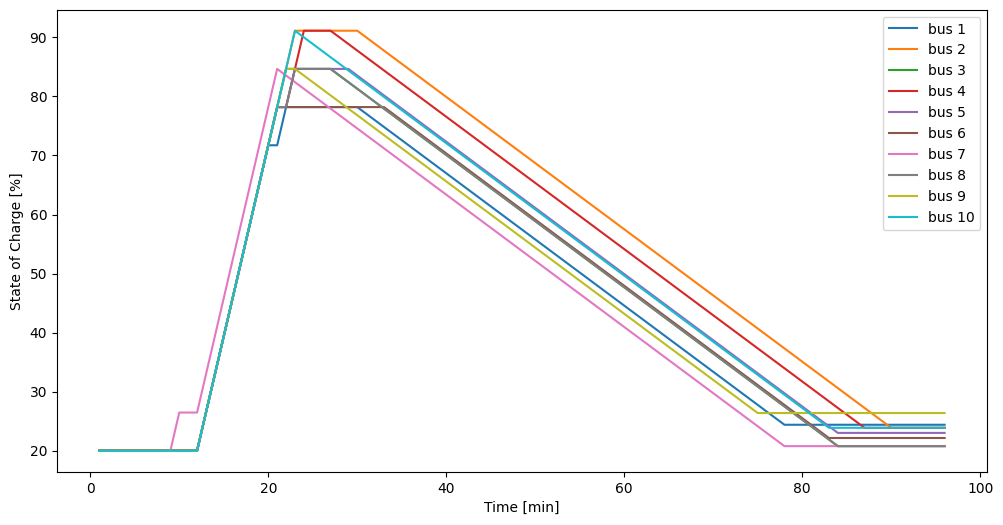

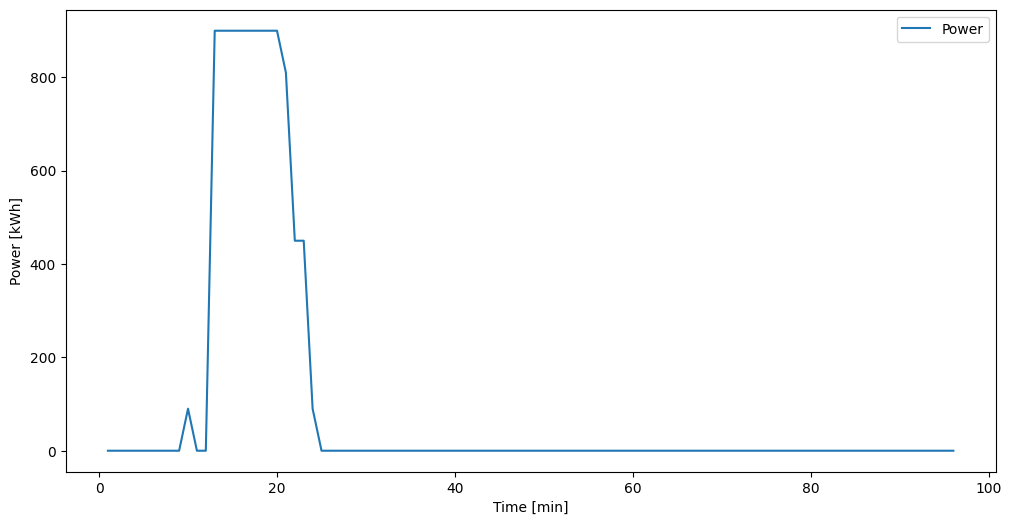

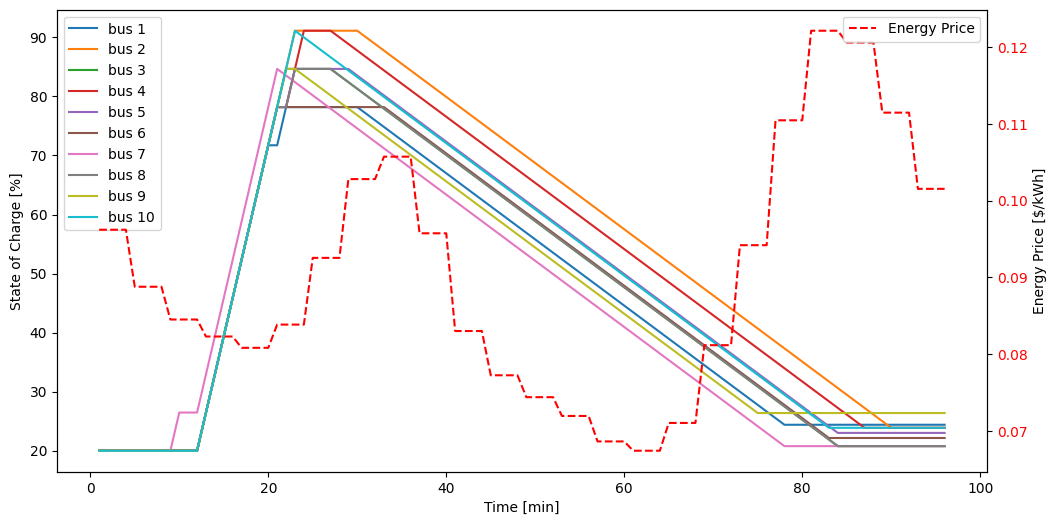

In [14]:
energy, energy_perc = plot_energy(model.K,model.T,model.e)
power = plot_power(model.T,model.w_buy, delta_t)
plot_energy_and_price(model.K,model.T,model.e,P)


In [15]:
energy.describe()

,bus 1,bus 2,bus 3,bus 4,bus 5,bus 6,bus 7,bus 8,bus 9,bus 10
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,155.240625,184.303125,160.987498,176.521875,166.318750,160.146875,149.906250,160.753125,155.584375,167.240625
std,72.111282,85.113323,79.123459,82.735359,78.893179,75.348177,74.362456,78.755984,72.097242,80.033378
min,69.600000,69.600000,69.600000,69.600000,69.600000,69.600000,69.600000,69.600000,69.600000,69.600000
25%,84.900000,101.625000,72.299997,91.800000,80.100000,77.100000,72.300000,72.300000,91.800000,83.100000
50%,141.450000,181.350000,152.249997,170.850000,158.850000,153.150000,135.900000,152.250000,137.850000,158.400000
75%,222.375000,259.575000,229.274997,249.900000,237.075000,230.175000,213.675000,229.275000,217.575000,236.175000
max,272.100000,317.100000,294.599997,317.100000,294.600000,272.100000,294.600000,294.600000,294.600000,317.100000


In [16]:
energy_perc.describe()

,bus 1,bus 2,bus 3,bus 4,bus 5,bus 6,bus 7,bus 8,bus 9,bus 10
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,44.609375,52.960668,46.260775,50.724677,47.792744,46.019217,43.076509,46.193427,44.708154,48.057651
std,20.721633,24.457851,22.736626,23.774528,22.670454,21.651775,21.368522,22.631030,20.717598,22.998097
min,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
25%,24.396552,29.202586,20.775861,26.379310,23.017241,22.155172,20.775862,20.775862,26.379310,23.879310
50%,40.646552,52.112069,43.749999,49.094828,45.646552,44.008621,39.051724,43.750000,39.612069,45.517241
75%,63.900862,74.590517,65.883620,71.810345,68.125000,66.142241,61.400862,65.883621,62.521552,67.866379
max,78.189655,91.120690,84.655172,91.120690,84.655172,78.189655,84.655172,84.655172,84.655172,91.120690


In [17]:
power.describe()

,Power
count,96.000000
mean,94.687500
std,265.500334
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,900.000000


## Save the results

---

Use this code to save the results in a external excel file

In [18]:
# Save all data to one Excel file with multiple sheets
with pd.ExcelWriter('output.xlsx') as writer:
    energy.to_excel(writer, sheet_name='Energy')
    energy_perc.to_excel(writer, sheet_name='Energy_Percentage')
    power.to_excel(writer, sheet_name='Power')